## ELEC4840 Assignment 1

Name: Kritika Pramod Wangikar

Student ID: 21012563

- Problem 1 (40%)

- Problem 2 (60%)

In [12]:
# import packages
import torch
from torch import nn
from torchvision import datasets, transforms
from tqdm import tqdm

## HINT
You should run training on __training dataset__, validate the model's performance during training using __validation dataset__. After finishing training, select the model that has the best performance on validation dataset, then report the model's performance based on the data of the __test dataset__.

In [13]:
# load FashionMNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=0.5,
        std=0.5
    )
])

data_train = datasets.FashionMNIST(
    root="./data/",
    transform=transform,
    train=True,
    download=True
)

data_test = datasets.FashionMNIST(
    root="./data/",
    transform=transform,
    train=False
)

split_train_size = int(0.8*(len(data_train)))
split_valid_size = len(data_train) - split_train_size

train_set, valid_set = torch.utils.data.random_split(
    data_train, [split_train_size, split_valid_size])

loader_train = torch.utils.data.DataLoader(
    dataset=train_set,
    batch_size=64,
    shuffle=True
)

loader_valid = torch.utils.data.DataLoader(
    dataset=valid_set,
    batch_size=64,
    shuffle=False
)

loader_test = torch.utils.data.DataLoader(
    dataset=data_test,
    batch_size=64,
    shuffle=False
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 110MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.78MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 57.2MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.6MB/s]


### Problem 1. Train an MLP network on the FashionMNIST dataset (40%)

Use a four-layer MLP to train the FashionMNIST dataset.

| Layer |  Type   |     Input      |    Output    | Activation |
| :---: | :-----: | :------------: | :----------: | :--------: |
|   1   | Linear  |   28 × 28      |     256      |    ReLU    |
|   2   | Linear  |      256       |     128      |    ReLU    |
|   3   | Dropout |      128       |     128      |     -      |
|   4   | Linear  |      128       |      64      |    ReLU    |
|   5   | Dropout |       64       |      64      |     -      |
|   6   | Linear  |       64       |      10      |     -      |


a.) Implement the function `__init__` and `forward` in the class `Model` (15%);

b.) Implement the training and testing code (15%).

c.) Plot the curve of training & validation accuracy and training loss (5%). During the testing stage, compare and discuss the results' difference between the model with / without dropout operation (5%).

In [14]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        ## ----- write your code here
        # first linear layer
        self.fc1 = nn.Linear(28*28, 256)
        self.relu1 = nn.ReLU()

        # second linear layer
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()

        # First dropout layer (after fc2)
        self.dropout1 = nn.Dropout(p=0.5)  # typical dropout rate is 0.5

        # Third linear layer: 128 to 64
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()

        # Second dropout layer (after fc3)
        self.dropout2 = nn.Dropout(p=0.5)

        # Fourth linear layer: 64 to 10 (output layer, no activation)
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        ## ----- write your code here
        ## Remember to return the output and delete the 'pass' command below
        # (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.view(x.size(0), -1)

        # Layer 1: Linear + ReLU
        x = self.fc1(x)
        x = self.relu1(x)

        # Layer 2: Linear + ReLU
        x = self.fc2(x)
        x = self.relu2(x)

        # Layer 3: Dropout
        x = self.dropout1(x)

        # Layer 4: Linear + ReLU
        x = self.fc3(x)
        x = self.relu3(x)

        # Layer 5: Dropout
        x = self.dropout2(x)

        # Layer 6: Linear (no activation)
        x = self.fc4(x)

        return x

In [15]:
max_epoch = 20
use_cuda = True

# model initialization
model = Model()
if use_cuda:
    model = model.cuda()

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

loss_list = []
acc_train_list = []
acc_valid_list = []

best_valid_loss = float('inf')

for epoch in range(max_epoch):
    running_loss = 0.0
    running_correct = 0
    valid_loss = 0.0
    valid_correct = 0
    print(" -- Epoch {}/{}".format(epoch + 1, max_epoch))

    # training
    # call a function to control the dropout behaviour
    # your code here
    model.train()

    for data in tqdm(loader_train):
        # set all gradients to zero
        optimizer.zero_grad()

        # fetch data
        images, labels = data
        if use_cuda:
            images = images.cuda()
            labels = labels.cuda()

        # model forward
        outputs = model(images)

        # calculate loss
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        pred = torch.argmax(outputs, dim=1)
        running_loss += loss.item()
        running_correct += torch.sum(pred == labels).item()


    # record loss, accuracy
    loss = running_loss / len(train_set)
    loss_list.append(loss)
    acc_train = running_correct / len(train_set)
    acc_train_list.append(acc_train)

    # validation

    # call a function to control the dropout behaviour
    # your code here
    model.eval()

    valid_correct = 0
    for data in loader_valid:
        # fetch data
        images, labels = data
        if use_cuda:
            images = images.cuda()
            labels = labels.cuda()
        # model forward
        outputs = model(images)
        # calculate loss
        loss = criterion(outputs, labels)
        valid_loss += loss.item()
        #calculate validation accurary
        pred = torch.argmax(outputs, dim=1)
        valid_correct += torch.sum(pred == labels).item()

    # Save best checkpoint
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_checkpoint_fashionmnist.pt')

    acc_valid = valid_correct / len(valid_set)
    acc_valid_list.append(acc_valid)
    print("Loss {:.4f}, Train Accuracy {:.4f}%, Validation Accuracy {:.4f}%".format(
        loss,
        acc_train * 100,
        acc_valid * 100
    ))

# testing

model.load_state_dict(torch.load('best_checkpoint_fashionmnist.pt'))

# call a function to control the dropout behaviour
# your code here
model.eval()

test_loss = 0.0
correct = 0
total = 0
with torch.no_grad():
    for images, labels in loader_test:
        # fetch data
        if use_cuda:
            images = images.cuda()
            labels = labels.cuda()
        # model forward
        outputs = model(images)
        # calculate accuracy on test set
        pred = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += torch.sum(pred == labels).item()

acc_test=correct/total
print("Best model on test set: Test Accuracy {:.4f}%".format(
        acc_test * 100
    ))

 -- Epoch 1/20


100%|██████████| 750/750 [00:12<00:00, 60.91it/s]


Loss 0.4113, Train Accuracy 64.4292%, Validation Accuracy 81.2583%
 -- Epoch 2/20


100%|██████████| 750/750 [00:12<00:00, 62.13it/s]


Loss 0.3911, Train Accuracy 80.5292%, Validation Accuracy 83.1417%
 -- Epoch 3/20


...

Loss 0.2712, Train Accuracy 89.8750%, Validation Accuracy 88.2250%
 -- Epoch 19/20


100%|██████████| 750/750 [00:12<00:00, 61.86it/s]


Loss 0.2785, Train Accuracy 89.9292%, Validation Accuracy 88.4417%
 -- Epoch 20/20


100%|██████████| 750/750 [00:12<00:00, 62.23it/s]


Loss 0.2507, Train Accuracy 90.1375%, Validation Accuracy 88.7917%
Best model on test set: Test Accuracy 88.3600%


c.) Plot loss and accuracy curve

In the previous cell, you have recorded the training loss and train/valid accuracy in `loss_list`, `acc_train_list`, and `acc_valid_list`, respectively. In this problem, you are required to plot two figures: 1.) training loss curve (5%); 2.) training and validation accuracy curves in the same figure (5%).

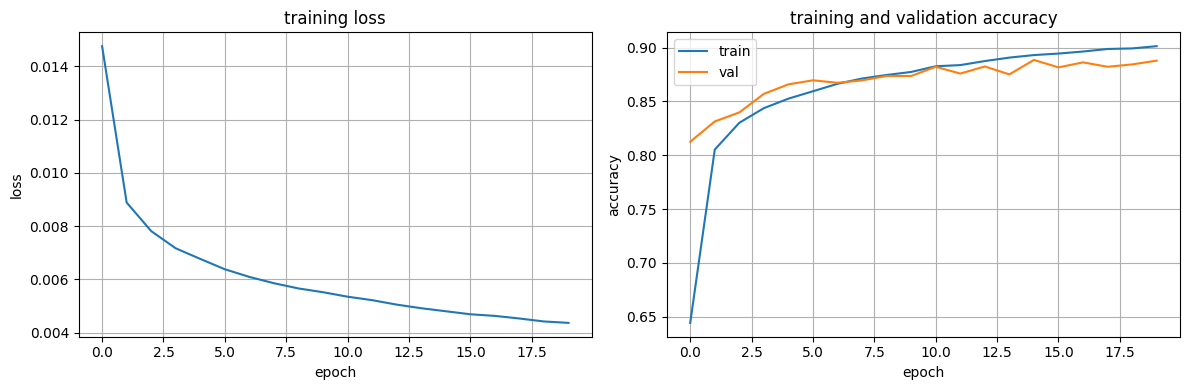

In [16]:
import numpy as np
from matplotlib import pyplot as plt

## ----- write your code here
# plot 1: training loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_list)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training loss')
plt.grid(True)

# plot 2: training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(acc_train_list, label='train')
plt.plot(acc_valid_list, label='val')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('training and validation accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Problem 2: Train a LeNet network on the BreastMNIST dataset

### The requirements are listed as follows:

#### 1. Data description: (5%)

(1) Randomly pick some samples and view individual images from the dataset;  
(2) Analyze the distribution of labels in the dataset.

#### 2. Data augmentation (5%)

Apply data augmentation (random horizontal flipping and ±10° rotation) to the dataset and visualize several augmented images. Please note that the augmentation should be performed only on the training set.

#### 3. Training, validation and testing

You should perform training on training set, monitor the network's performance and select the best-performing model parameters during training using validation set, and report your results on test set. Please note that test set should be kept out of training process until you need to test your model.

#### 4. LeNet implementation (15%)

Implement a LeNet classification network for the breast cancer classification task, including the model, dataloader and training-validation-test procedures.

#### 5. Performance metrics (10%)

Report accuracy, precision, recall, specificity, one-versus-rest AUROC, and negative predictive value (NPV) on the test set, and achieve at least 60% accuracy.

#### 6. Visualization (10%)

Plot one-versus-rest ROC curve, training & validation loss curves, training & validation accuarcy curves.

#### 7. Result analysis (15%)

Analyze your results from the following perspectives:

(1) How is your model performing on different classes in terms of different metrics (accuracy, precision, ...)?  

(2) How will the model's performance affect the decision of the doctors? (Hint: You can use what you learned from Lecture 2 Page 87 to give your opinion)  

(3) What potential issue you had identified during the training and testing process of your model?

Generally, the training progress is the same as problem 1.

Differences:
- Dataset: FashionMNIST --> BreastMNIST
- Model: MLP --> LeNet

### Prepare environment

In [2]:
# import packages
import torch
from torch import nn
from torch.nn import functional as F
from torchvision import datasets, transforms
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

### Prepare Dataset
The [BreastMNIST](https://medmnist.com/) dataset is composed of 780 breast ultrasound images for a binary classification task.

Data augmentation is needed in this problem. The *transform* function is defined here.

In [3]:
def get_transform(mode):
  if mode == "train":
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),           # random horizontal flip
        transforms.RandomRotation(degrees=10),          # random rotation (±10°)
        transforms.ToTensor(),
        transforms.Normalize(
            mean=0.5,
            std=0.5
        )
    ])
  else:  # only perform the data augmentation in the training set
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=0.5,
            std=0.5
        )
    ])

The MedMNIST package needs to be installed before downloading the data.

In [4]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.0 MB/s eta 0:00:00


In [5]:
from medmnist import BreastMNIST

# create BreastMNIST dataset
train_set = BreastMNIST(
    split="train",
    transform=get_transform("train"),
    download=True
)

valid_set = BreastMNIST(
    split="val",
    transform=get_transform("val"),
    download=True
)

test_set = BreastMNIST(
    split="test",
    transform=get_transform("test"),
    download=True
)

# we use the official split of the dataset
print(f'train set size: {len(train_set)}, validation set size: {len(valid_set)}, test set size: {len(test_set)}')

# create dataloader
loader_train = torch.utils.data.DataLoader(
    dataset=train_set,
    batch_size=64,
    shuffle=True
)

loader_valid = torch.utils.data.DataLoader(
    dataset=valid_set,
    batch_size=64,
    shuffle=False
)

loader_test = torch.utils.data.DataLoader(
    dataset=test_set,
    batch_size=64,
    shuffle=False
)

100%|██████████| 560k/560k [00:00<00:00, 5.42MB/s]

train set size: 546, validation set size: 78, test set size: 156


### Visualize images and Class distribution

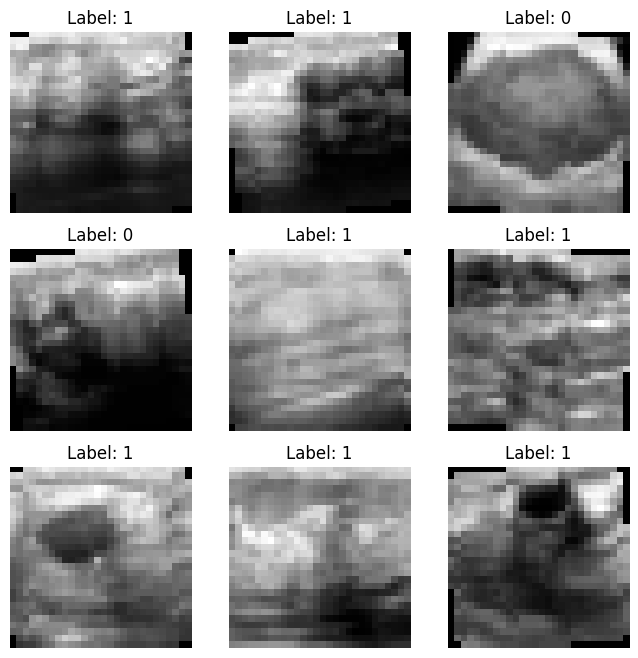

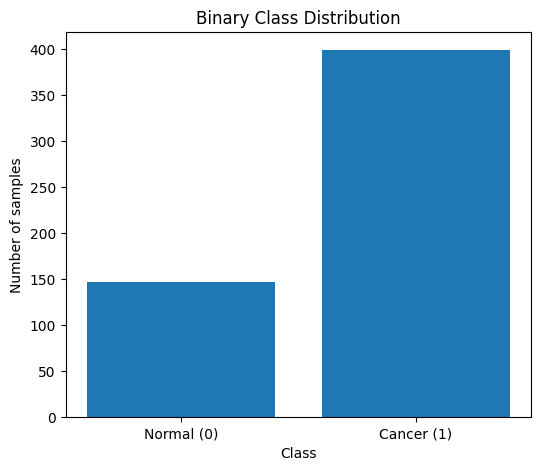

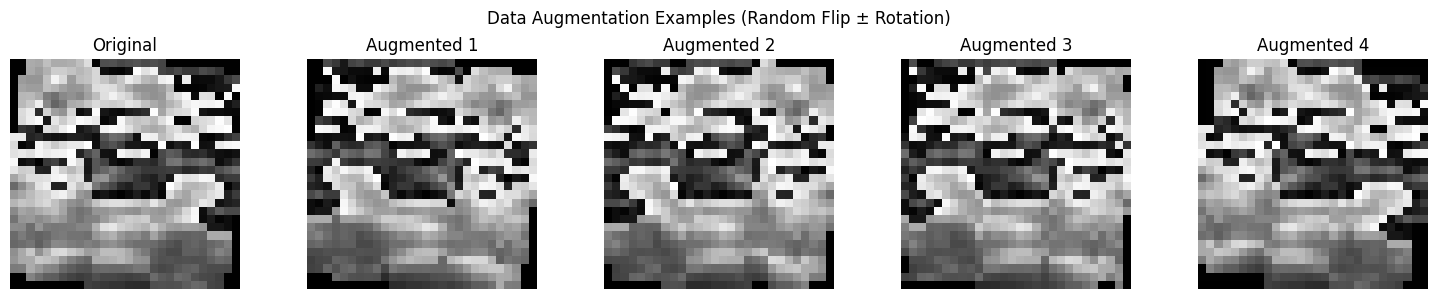


===== Class Distribution Table =====
Class	Count	%
-------------------------
Normal	147	26.9%
Cancer	399	73.1%
-------------------------
Total	546	100%


In [6]:
# =========================
# Part 1: Visualize images
# =========================

import torch
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):

    # write your code here
    idx = torch.randint(len(train_set), size=(1,)).item()
    image, label = train_set[idx]

    figure.add_subplot(rows, cols, i)
    plt.axis("off")

    # write your code here
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f'Label: {label.item()}')

plt.show()


# =========================
# Part 2: Class distribution
# =========================

labels = []

for i in range(len(train_set)):

    # write your code here
    # get the label for each sample
    _, label = train_set[i]
    labels.append(label.item())

# write your code here
# count samples in each class
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(6, 5))

# write your code here
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Binary Class Distribution")
plt.xticks(unique, ['Normal (0)', 'Cancer (1)'])
plt.show()

# Figure 4: Visualize Augmented Images
# Get one sample from training set
sample_image, sample_label = train_set[0]  # Remove .dataset

# Convert to PIL for augmentation
if isinstance(sample_image, torch.Tensor):
    pil_image = transforms.ToPILImage()(sample_image)
else:
    pil_image = sample_image

# Create the same augmentation transform used in training
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
])

# Plot original and 4 augmented versions
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Original
axes[0].imshow(np.array(pil_image), cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Generate 4 augmented versions
for i in range(4):
    # Apply augmentation
    aug_tensor = augment_transform(pil_image)
    aug_image = aug_tensor.squeeze().numpy()

    axes[i+1].imshow(aug_image, cmap='gray')
    axes[i+1].set_title(f'Augmented {i+1}')
    axes[i+1].axis('off')

plt.suptitle('Data Augmentation Examples (Random Flip ± Rotation)')
plt.tight_layout()
plt.show()
# -------
total = len(labels)
normal_count = counts[0]  # Class 0
cancer_count = counts[1]  # Class 1
normal_pct = (normal_count / total) * 100
cancer_pct = (cancer_count / total) * 100

print("\n===== Class Distribution Table =====")
print("Class\tCount\t%")
print("-" * 25)
print(f"Normal\t{normal_count}\t{normal_pct:.1f}%")
print(f"Cancer\t{cancer_count}\t{cancer_pct:.1f}%")
print("-" * 25)
print(f"Total\t{total}\t100%")

### Prepare Model
#### [LeNet](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf)
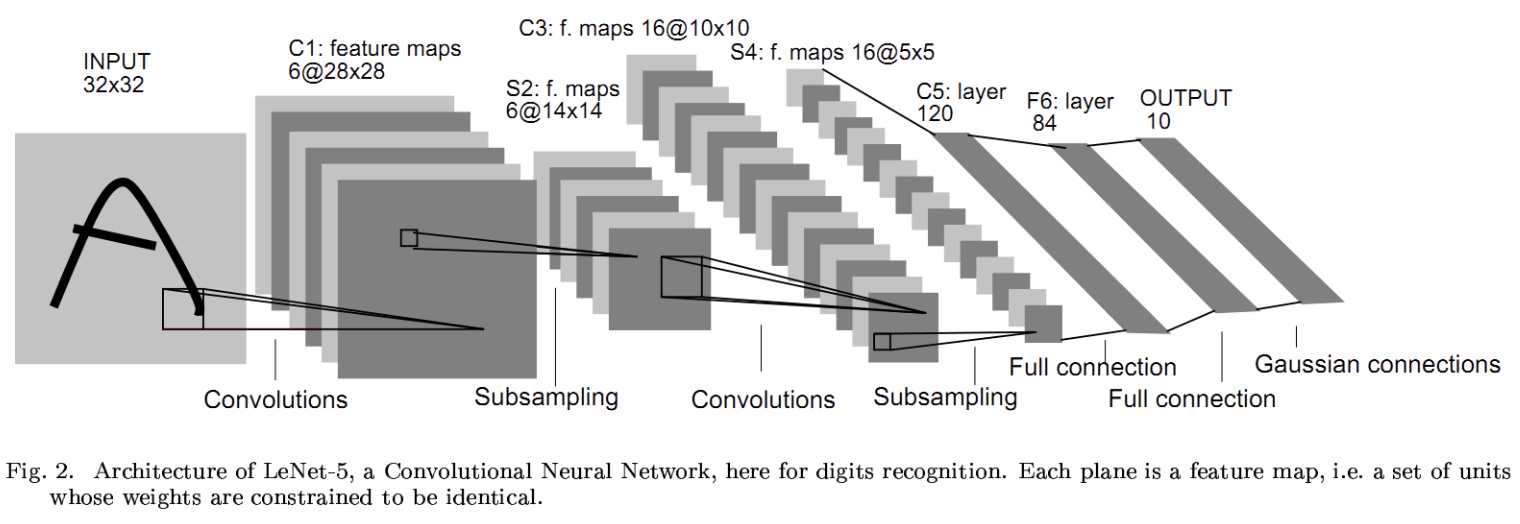

The architecture of LeNet used for problem 2.

| Layer |  Type  |       Out Channel       |      Feature Size       |  Kernel Size  | Stride | Activation |
| :---: | :----: | :---------------: | :---------------: | :-----------: | :--------: | :--------: |
|   1   | Convolutional |      6      |         28*28         |    5*5    | 1 | ReLU |
|   2   | Pooling |         6  |   14*14 | 2*2    |        2         |    -    |
|   3   | Convolutional |      16      |         10*10         |    5*5    | 1 | ReLU |
|   4   | Pooling |         16  |   5*5 | 2*2    |        2         |    -    |
|   5   | Convolutional |      120      |         1*1         |    5*5    | 1 | ReLU |
|   6   | Linear |      -      |         84        |    -    | - | ReLU |
|   7   | Linear |      -      |         2        |    -    | - | - |

[Convolutional layer](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html): `nn.Conv2d(in_channel, out_channel, kernel_size, stride, padding)`

[Pooling layer](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html): `nn.MaxPool2d(kernel_size, stride)`

[Linear layer](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html): `nn.Linear(in_features, out_features)`

Our input image size is 28 × 28 grayscale. To keep the feature map size unchanged after the first convolution (kernel size = 5, stride = 1), you should set `padding` to 2.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class LeNet(nn.Module):

    def __init__(self, num_classes):
        super(LeNet, self).__init__()

        # write your code here
        # layer 1: conv
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6,
                               kernel_size=5, stride=1, padding=2)
        # layer 2: pooling
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 3: conv
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16,
                               kernel_size=5, stride=1)

        # layer 4: pooling
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 5: conv
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=120,
                               kernel_size=5, stride=1)
        # layer 6: linear
        self.fc1 = nn.Linear(120, 84)

        # layer 7: linear
        self.fc2 = nn.Linear(84, num_classes)

        # activation function
        self.relu = nn.ReLU()


    def forward(self, x):

        # write your code here

        # layer 1: conv + ReLU
        x = self.conv1(x)
        x = self.relu(x)

        # layer 2: pooling
        x = self.pool1(x)

        # layer 3: conv + ReLU
        x = self.conv2(x)
        x = self.relu(x)

        # layer 4: pooling
        x = self.pool2(x)

        # layer 5: conv + ReLU
        x = self.conv3(x)
        x = self.relu(x)

        # flatten for fully connected layers
        x = x.view(x.size(0), -1)

        # layer 6: linear + ReLU
        x = self.fc1(x)
        x = self.relu(x)

        # layer 7: linear (no activation)
        x = self.fc2(x)

        return x

### Model Training
The model training process is the same as problem 1.

In [8]:
max_epoch = 30
use_cuda = True

# model initialization
model = LeNet(num_classes=2)
if use_cuda:
    model = model.cuda()

# loss function
criterion = nn.CrossEntropyLoss()
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss_list = []
acc_train_list = []
acc_valid_list = []
valid_loss_list = []
best_valid_loss = float('inf')

for epoch in range(max_epoch):
    running_loss = 0.0
    running_correct = 0
    valid_loss = 0.0
    valid_correct = 0
    print(" -- Epoch {}/{}".format(epoch + 1, max_epoch))

    # training
    # call a function to control the dropout behaviour
    # your code here
    model.train()

    for data in tqdm(loader_train):
        # set all gradients to zero
        optimizer.zero_grad()

        # fetch data
        images, labels = data
        if use_cuda:
            images = images.cuda()
            labels = labels.cuda()

        labels = labels.squeeze().long()

        # model forward
        outputs = model(images)

        # calculate loss
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        pred = torch.argmax(outputs, dim=1)
        running_loss += loss.item()
        running_correct += torch.sum(pred == labels).item()


    # record loss, accuracy
    loss = running_loss / len(train_set)
    loss_list.append(loss)
    acc_train = running_correct / len(train_set)
    acc_train_list.append(acc_train)

    # validation

    # call a function to control the dropout behaviour
    # your code here
    model.eval()

    valid_correct = 0
    valid_loss = 0.0
    for data in loader_valid:
        # fetch data
        images, labels = data
        if use_cuda:
            images = images.cuda()
            labels = labels.cuda()

        labels = labels.squeeze().long()

        # model forward
        outputs = model(images)
        # calculate loss
        loss = criterion(outputs, labels)
        valid_loss += loss.item()
        # calculate accuracy
        pred = torch.argmax(outputs, dim=1)
        valid_correct += torch.sum(pred == labels).item()

    avg_valid_loss = valid_loss / len(valid_set)
    valid_loss_list.append(avg_valid_loss)

    # Save best checkpoint
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_checkpoint_breastmnist.pt')

    acc_valid = valid_correct / len(valid_set)
    acc_valid_list.append(acc_valid)
    print("Loss {:.4f}, Train Accuracy {:.4f}%, Validation Accuracy {:.4f}%".format(
        loss,
        acc_train * 100,
        acc_valid * 100
    ))

 -- Epoch 1/30


100%|██████████| 9/9 [00:01<00:00,  4.86it/s]


Loss 0.6768, Train Accuracy 65.3846%, Validation Accuracy 73.0769%
 -- Epoch 2/30


100%|██████████| 9/9 [00:00<00:00, 46.21it/s]


Loss 0.6440, Train Accuracy 73.0769%, Validation Accuracy 73.0769%
 -- Epoch 3/30


...

Loss 0.2660, Train Accuracy 83.3333%, Validation Accuracy 88.4615%
 -- Epoch 29/30


100%|██████████| 9/9 [00:00<00:00, 45.80it/s]


Loss 0.2898, Train Accuracy 84.0659%, Validation Accuracy 88.4615%
 -- Epoch 30/30


100%|██████████| 9/9 [00:00<00:00, 43.32it/s]

Loss 0.3183, Train Accuracy 85.5311%, Validation Accuracy 88.4615%


#### Visualize the training process
Plot the training & validation loss curves, training & validation accuarcy curves.

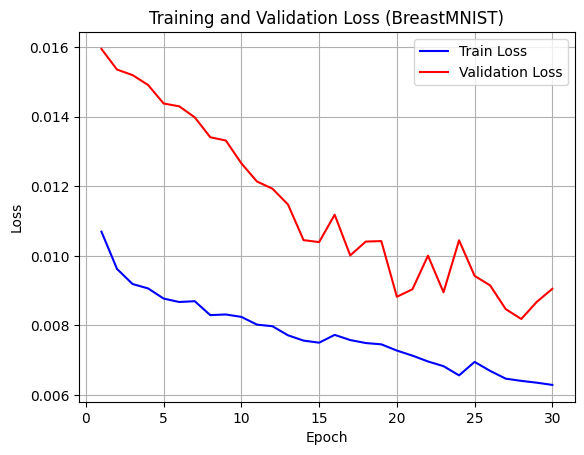

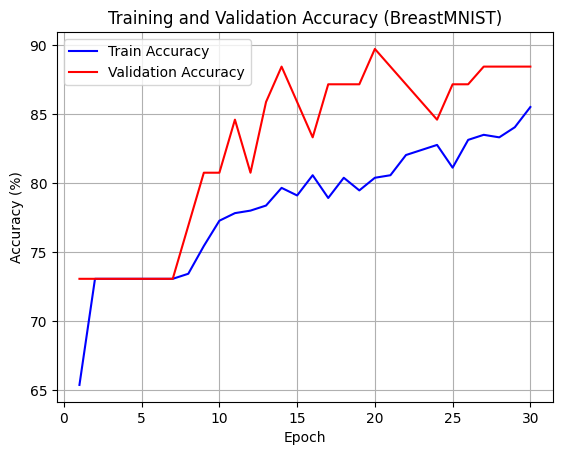

In [9]:
# epoch number
epochs = range(1, max_epoch + 1)

# ---------------------------
# Plot Loss Curve
# ---------------------------
plt.figure()
# write your code here
plt.plot(epochs, loss_list, 'b-', label='Train Loss')
plt.plot(epochs, valid_loss_list, 'r-', label='Validation Loss')
plt.title("Training and Validation Loss (BreastMNIST)")
plt.legend(["Train Loss", "Validation Loss"])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Training and Validation Loss (BreastMNIST)")
plt.legend(["Train Loss", "Validation Loss"])
plt.grid(True)
plt.show()

# ---------------------------
# Plot Accuracy Curve
# ---------------------------
plt.figure()
# write your code here
plt.plot(epochs, [acc*100 for acc in acc_train_list], 'b-', label='Train Accuracy')
plt.plot(epochs, [acc*100 for acc in acc_valid_list], 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title("Training and Validation Accuracy (BreastMNIST)")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.grid(True)
plt.show()

#### Test Progress

First, load from the best checkpoint.

Next, run on the test dataset and report the performance.

In [10]:
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, confusion_matrix )
model.load_state_dict(torch.load('best_checkpoint_breastmnist.pt'))

# evaluation mode
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in loader_test:

        # write your code here (data preparation)
        if use_cuda:
            images = images.cuda()
            labels = labels.cuda()
        labels = labels.squeeze().long()

        # write your code here (forward pass)
        outputs = model(images)

        # write your code here (probability computation)
        probs = F.softmax(outputs, dim=1)

        threshold = 0.3
        # write your code here (prediction)
        _, predicted = torch.max(outputs, 1)

        # write your code here (collect results)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())


# Convert to numpy
# write your code here
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Confusion Matrix
# write your code here
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix:")
print("              Predicted")
print("              Neg   Pos")
print(f"Actual Neg   {tn:4d}  {fp:4d}")
print(f"       Pos   {fn:4d}  {tp:4d}")

# Metric computation
# write your code here
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
specificity = tn / (tn + fp)
npv = tn / (tn + fn)
auroc = roc_auc_score(all_labels, all_probs[:, 1])



# write your code here

print("===== Test Metrics =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Negative Predictive Value (NPV): {npv:.4f}")
print(f"One-vs-Rest AUROC: {auroc:.4f}")


print(f"True Negatives (TN): {tn} - Normal correctly identified")
print(f"False Positives (FP): {fp} - False alarms (normal predicted as cancer)")
print(f"False Negatives (FN): {fn} - Cancer missed (most dangerous!)")
print(f"True Positives (TP): {tp} - Cancer correctly identified")



Confusion Matrix:
              Predicted
              Neg   Pos
Actual Neg     21    21
       Pos      6   108
===== Test Metrics =====
Accuracy: 0.8269
Precision: 0.8372
Recall (Sensitivity): 0.9474
Specificity: 0.5000
Negative Predictive Value (NPV): 0.7778
One-vs-Rest AUROC: 0.8300
True Negatives (TN): 21 - Normal correctly identified
False Positives (FP): 21 - False alarms (normal predicted as cancer)
False Negatives (FN): 6 - Cancer missed (most dangerous!)
True Positives (TP): 108 - Cancer correctly identified


Plot the one-versus-rest AUROC curve.

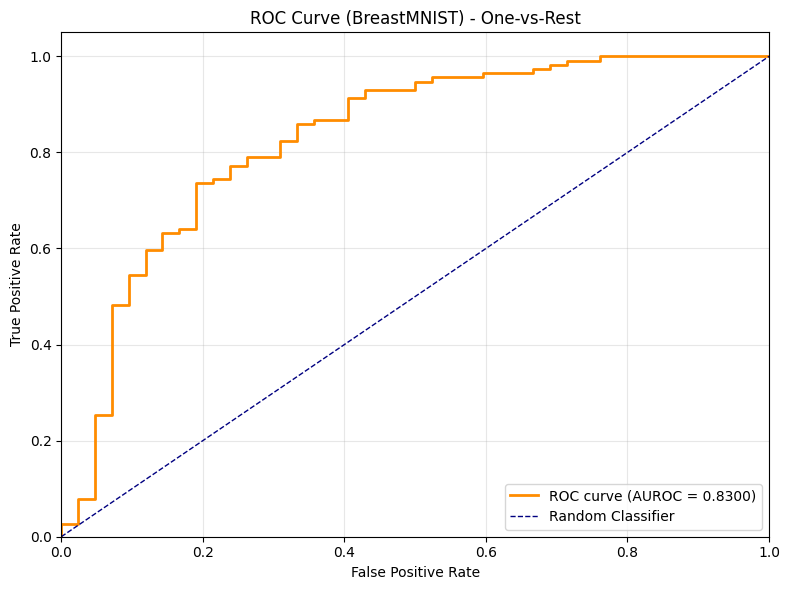

In [11]:
# Compute ROC curve
from sklearn.metrics import roc_curve, auc

# write your code here
fpr, tpr, thresholds = roc_curve(all_labels, all_probs[:, 1])


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUROC = {auroc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (BreastMNIST) - One-vs-Rest")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()